In [ ]:
# Task 1: Problem Identification
#Image Classification Problem
# because the task involves assigning one label to each product image based on the visible surface defect type.

In [ ]:
Task 2: Dataset Exploration
Analyze the image dataset.

Include:

Number of classes
Number of images per class
Sample images from each class
Image dimensions
Any imbalance in the dataset

In [2]:
import os
import pandas as pd
dataset_path = "images"
classes = os.listdir(dataset_path)
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['dent', 'normal', 'scratch', 'stain']
Number of classes: 4


In [3]:
for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(f"{cls}: {len(os.listdir(path))} images")

dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


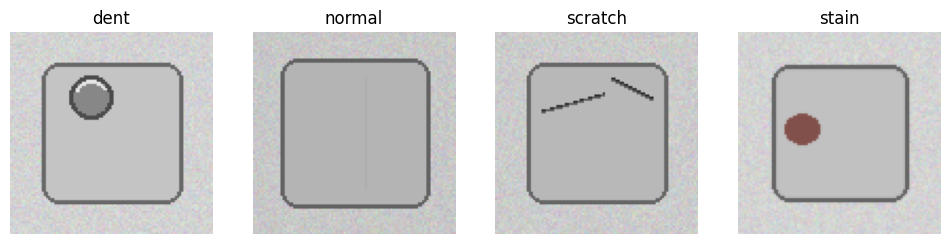

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
plt.figure(figsize=(12,5))
for i, cls in enumerate(classes):
    img_path = os.path.join(dataset_path,cls,os.listdir(os.path.join(dataset_path, cls))[0])
    img = Image.open(img_path)
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [5]:
for cls in classes:
    
    img_path = os.path.join(
        dataset_path,
        cls,
        os.listdir(os.path.join(dataset_path, cls))[0]
    )
    
    img = Image.open(img_path)
    
    print(cls, "Image Size:", img.size)

dent Image Size: (96, 96)
normal Image Size: (96, 96)
scratch Image Size: (96, 96)
stain Image Size: (96, 96)


In [ ]:
#The dataset is balanced because all four classes contain an equal number of images (120 images each). Therefore, no additional balancing techniques such as oversampling, 
# undersampling, or class weighting were required during training.

In [6]:
#Task 3: Image Preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = 128
BATCH_SIZE = 32
# Data augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Training data
train_generator = train_datagen.flow_from_directory(
    "images/",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation/Test data
validation_generator = train_datagen.flow_from_directory(
    "images/",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Creating CNN model
model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))
# Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))
# Third Convolution Layer
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))
# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))
# Output Layer
model.add(Dense(4, activation='softmax'))

# -------------------------------
# Compile Model
# -------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Task 5: Model Training and Evaluation
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)


Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 696ms/step - accuracy: 0.2552 - loss: 1.4526 - val_accuracy: 0.2500 - val_loss: 1.3895
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 682ms/step - accuracy: 0.3073 - loss: 1.3854 - val_accuracy: 0.3438 - val_loss: 1.3775
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 747ms/step - accuracy: 0.2708 - loss: 1.3753 - val_accuracy: 0.3229 - val_loss: 1.3372
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 554ms/step - accuracy: 0.3750 - loss: 1.2953 - val_accuracy: 0.3229 - val_loss: 1.2218
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 502ms/step - accuracy: 0.5521 - loss: 1.0590 - val_accuracy: 0.5208 - val_loss: 1.0263
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 468ms/step - accuracy: 0.6380 - loss: 0.9030 - val_accuracy: 0.8229 - val_loss: 0.6068
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 404ms/step - accuracy: 0.7760 - loss: 0.6098 - val_accuracy: 0.8229 - val_loss: 0.5338
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 494ms/step - accuracy: 0.8099 - loss: 0.5103 - val_accuracy: 0

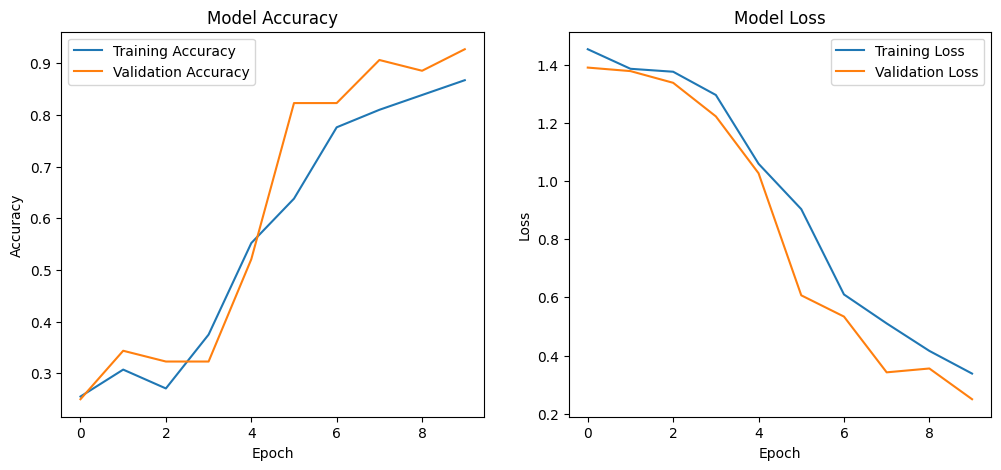

In [25]:
#Training Accuracy and Loss
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training Loss", "Validation Loss"])
plt.savefig("training_validation_plots.png")

plt.show()

In [24]:
#Testing performance
test_loss, test_accuracy = model.evaluate(validation_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.9062 - loss: 0.2513
Test Accuracy: 0.90625
Test Loss: 0.2512991726398468


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step


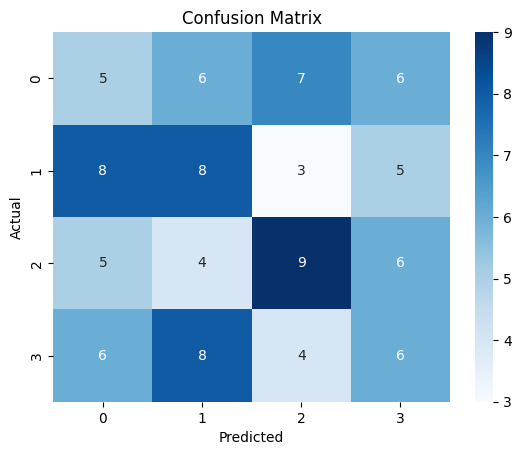

<Figure size 640x480 with 0 Axes>

In [15]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Predict classes
predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = validation_generator.classes

# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
plt.savefig('confusion_matrix.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


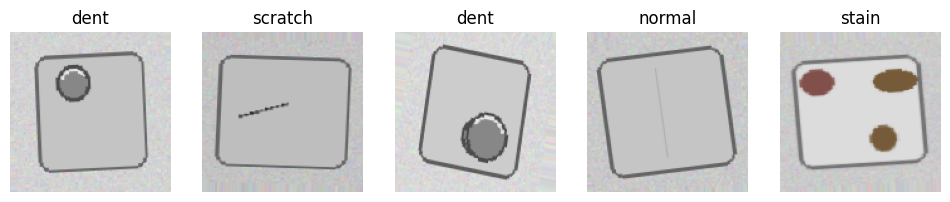

<Figure size 640x480 with 0 Axes>

In [14]:
images, labels = next(validation_generator)
predictions = model.predict(images)
class_names = list(train_generator.class_indices.keys())
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    predicted_label = np.argmax(predictions[i])
    plt.title(class_names[predicted_label])
    plt.axis("off")
plt.show()
plt.savefig('prediction_outputs.png')